In [10]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Load Data


In [2]:
data = pd.read_csv("preprocessed_diabetes.csv")  # Example: local CSV
print("Data shape:", data.shape)
data.head()

Data shape: (667, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,5,116.0,74.0,27.0,102.5,25.6,0.201,30,0


In [ ]:

print(data.info())
print(data.describe())
if 'Outcome' in data.columns:
    print("\nValue counts for Outcome:")
    print(data['Outcome'].value_counts())
print("\n--- Missing Values Count ---")
print(data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 667 entries, 0 to 666
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               667 non-null    int64  
 1   Glucose                   667 non-null    float64
 2   BloodPressure             667 non-null    float64
 3   SkinThickness             667 non-null    float64
 4   Insulin                   667 non-null    float64
 5   BMI                       667 non-null    float64
 6   DiabetesPedigreeFunction  667 non-null    float64
 7   Age                       667 non-null    int64  
 8   Outcome                   667 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 47.0 KB
None
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   667.000000  667.000000     667.000000     667.000000  667.000000   
mean      3.799100  118.236882      72.233883      28.629685  123.095952   
std    

In [5]:
if 'Outcome' in data.columns:
    corr_matrix = data.corr()
    print("\n--- Correlation with Outcome ---")
    print(corr_matrix['Outcome'].sort_values(ascending=False))


--- Correlation with Outcome ---
Outcome                     1.000000
Insulin                     0.586949
Glucose                     0.496328
BMI                         0.300445
SkinThickness               0.278935
Age                         0.245275
Pregnancies                 0.212646
BloodPressure               0.200925
DiabetesPedigreeFunction    0.181734
Name: Outcome, dtype: float64


# Feature selection

In [7]:

features_to_keep = ['Pregnancies', 'Glucose', 'BloodPressure', 
                    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

X = data[features_to_keep].copy()

print("Features used for clustering:", features_to_keep)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nScaled data shape:", X_scaled.shape)

Features used for clustering: ['Pregnancies', 'Glucose', 'BloodPressure', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Scaled data shape: (667, 7)


# K-means and optimal k

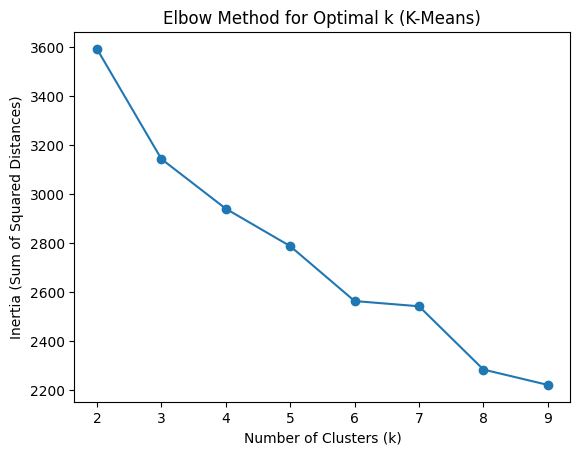

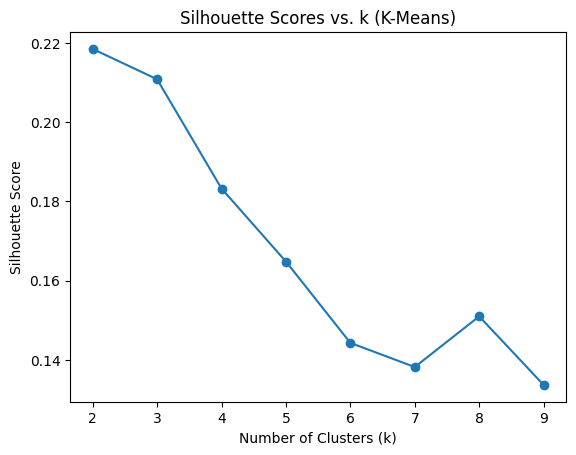

K=2, Silhouette Score=0.219
K=3, Silhouette Score=0.211
K=4, Silhouette Score=0.183
K=5, Silhouette Score=0.165
K=6, Silhouette Score=0.144
K=7, Silhouette Score=0.138
K=8, Silhouette Score=0.151
K=9, Silhouette Score=0.134

Choosing k = 3 for final K-Means.


In [11]:

# We'll use the Elbow method (inertia) and Silhouette scores.

inertias = []
sil_scores = []
K_range = range(2, 10)  # We try k=2 to k=9

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_SEED)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    
    labels = kmeans.labels_
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

# Plot the Elbow curve
plt.figure()
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Method for Optimal k (K-Means)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Sum of Squared Distances)")
plt.show()

# Plot the Silhouette scores
plt.figure()
plt.plot(K_range, sil_scores, marker='o')
plt.title("Silhouette Scores vs. k (K-Means)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

for k, sil_val in zip(K_range, sil_scores):
    print(f"K={k}, Silhouette Score={sil_val:.3f}")

# Decide on final 'k' using both visual & numeric analysis
# (example: if you aim for 3 risk groups, you might set k=3)
optimal_k = 3
print(f"\nChoosing k = {optimal_k} for final K-Means.")

# fit final k means model


In [12]:

kmeans_final = KMeans(n_clusters=optimal_k, random_state=RANDOM_SEED)
kmeans_final.fit(X_scaled)
cluster_labels = kmeans_final.labels_

# Attach labels to the original dataframe
data['Cluster_KMeans'] = cluster_labels

print("\n--- K-Means final cluster centers (scaled space) ---")
print(kmeans_final.cluster_centers_)

# Evaluate silhouette score for final model
final_silhouette = silhouette_score(X_scaled, cluster_labels)
print(f"Final K-Means Silhouette Score (k={optimal_k}): {final_silhouette:.3f}")

# Group stats in original feature space
cluster_profile = data.groupby('Cluster_KMeans')[features_to_keep].mean()
print("\n--- Average Feature Values by K-Means Cluster ---")
print(cluster_profile)


--- K-Means final cluster centers (scaled space) ---
[[ 1.04896725  0.05303231  0.48117212  0.03640837 -0.09835983 -0.29748128
   1.1467238 ]
 [-0.54452075 -0.5001501  -0.44838267 -0.56772012 -0.35948308 -0.18057057
  -0.67703966]
 [-0.09792718  0.8684305   0.32209323  1.01079561  0.76784456  0.64682415
   0.04405993]]
Final K-Means Silhouette Score (k=3): 0.211

--- Average Feature Values by K-Means Cluster ---
                Pregnancies     Glucose  BloodPressure     Insulin        BMI  \
Cluster_KMeans                                                                  
0                  7.222222  119.744444      77.672222  124.788889  31.341111   
1                  2.022152  104.018987      67.166139   96.697785  29.646835   
2                  3.479532  142.923977      75.874269  170.096491  36.961404   

                DiabetesPedigreeFunction        Age  
Cluster_KMeans                                       
0                               0.349794  45.094444  
1              

# comparison to DBSCAN

In [13]:
dbscan_model = DBSCAN(eps=1.5, min_samples=5)  # tweak eps/min_samples as needed
dbscan_labels = dbscan_model.fit_predict(X_scaled)

# Count how many clusters DBSCAN found (excluding noise label -1 if present)
unique_labels_dbscan = set(dbscan_labels)
n_clusters_dbscan = len(unique_labels_dbscan) - (1 if -1 in unique_labels_dbscan else 0)
n_noise_dbscan = list(dbscan_labels).count(-1)

print(f"\nDBSCAN found {n_clusters_dbscan} clusters (excluding noise).")
print(f"DBSCAN labeled {n_noise_dbscan} points as noise (-1).")

if n_clusters_dbscan > 1:
    dbscan_sil = silhouette_score(X_scaled, dbscan_labels)
    print(f"DBSCAN Silhouette Score: {dbscan_sil:.3f}")
else:
    print("DBSCAN does not form more than 1 cluster. Silhouette not applicable.")

# Attach DBSCAN labels for interpretation if desired
data['Cluster_DBSCAN'] = dbscan_labels

# Quick group stats if multiple clusters formed
if n_clusters_dbscan > 1:
    cluster_profile_dbscan = data[dbscan_labels != -1].groupby('Cluster_DBSCAN')[features_to_keep].mean()
    print("\n--- Average Feature Values by DBSCAN Cluster (excluding noise) ---")
    print(cluster_profile_dbscan)


DBSCAN found 3 clusters (excluding noise).
DBSCAN labeled 116 points as noise (-1).
DBSCAN Silhouette Score: -0.011

--- Average Feature Values by DBSCAN Cluster (excluding noise) ---
                Pregnancies     Glucose  BloodPressure     Insulin        BMI  \
Cluster_DBSCAN                                                                  
0                  3.381919  114.236162      70.701107  118.184502  31.252399   
1                  3.400000  143.200000      79.600000  102.500000  30.240000   
2                  6.500000  109.750000      84.500000   99.625000  38.400000   

                DiabetesPedigreeFunction        Age  
Cluster_DBSCAN                                       
0                               0.389402  30.112546  
1                               0.255000  62.600000  
2                               0.742000  32.000000  


# visualization (pca for 2d plotting

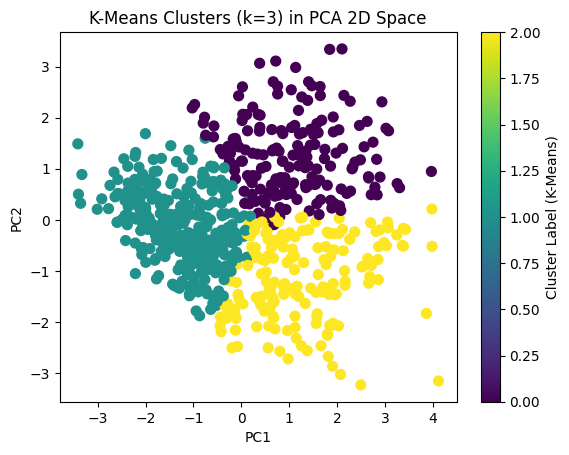

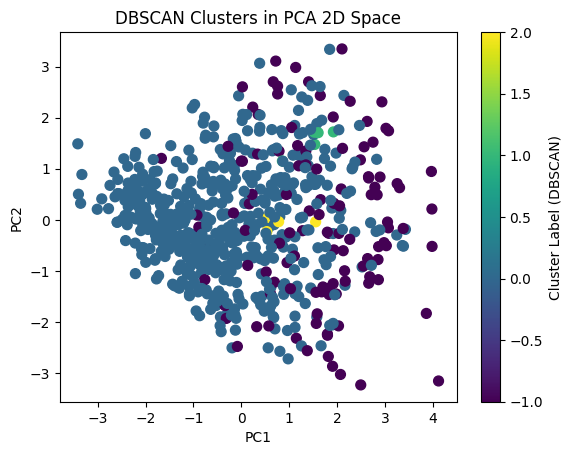

In [14]:
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_scaled)

# Plot K-Means clusters in 2D PCA space
plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, s=50)
plt.title("K-Means Clusters (k=3) in PCA 2D Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster Label (K-Means)")
plt.show()

# Plot DBSCAN clusters in 2D PCA space (optional)
if 'Cluster_DBSCAN' in data.columns:
    plt.figure()
    plt.scatter(X_pca[:,0], X_pca[:,1], c=dbscan_labels, s=50)
    plt.title("DBSCAN Clusters in PCA 2D Space")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.colorbar(label="Cluster Label (DBSCAN)")
    plt.show()

# analysis of outcome distribution


--- Outcome Distribution within Each K-Means Cluster ---
Outcome           0    1
Cluster_KMeans          
0               113   67
1               288   28
2                53  118


<Figure size 640x480 with 0 Axes>

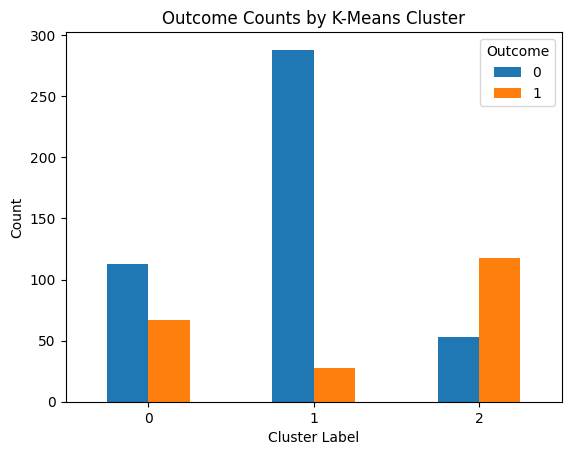

In [15]:
if 'Outcome' in data.columns:
    print("\n--- Outcome Distribution within Each K-Means Cluster ---")
    outcome_distribution = data.groupby(["Cluster_KMeans", "Outcome"]).size().unstack(fill_value=0)
    print(outcome_distribution)
    # You can interpret if certain clusters are mostly diabetic (1) vs. non-diabetic (0).

    # Possibly add a bar chart for a cluster vs. outcome distribution:
    plt.figure()
    outcome_distribution.plot(kind='bar')
    plt.title("Outcome Counts by K-Means Cluster")
    plt.xlabel("Cluster Label")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()

# Summary results

In [ ]:
print("\n--- CLUSTERING SUMMARY ---")
print("1. K-Means with k=3 yields a Silhouette Score of {:.3f}.".format(final_silhouette))
print("   The cluster centroids (in scaled space) suggest distinct groups.")
print("   By examining mean Glucose, BMI, etc., we can identify potential 'High Risk',")
print("   'Moderate Risk', 'Low Risk' segments.\n")

print("2. DBSCAN found {} clusters plus {} noise points.".format(n_clusters_dbscan, n_noise_dbscan))
print("   DBSCAN's performance depends heavily on eps/min_samples.")
if n_clusters_dbscan > 1:
    print("   DBSCAN Silhouette Score: {:.3f}.".format(dbscan_sil))

if 'Outcome' in data.columns:
    print("\nIn clusters heavily dominated by Outcome=1, we might label them 'Higher Risk'.")
    print("In clusters dominated by Outcome=0, we might label them 'Lower Risk' or 'Healthy'.\n")

print("Next steps might include hierarchical clustering, deeper domain knowledge,")
print("and analyzing partial feature sets (e.g., minimal biomarkers only).")



--- CLUSTERING SUMMARY ---
1. K-Means with k=3 yields a Silhouette Score of 0.211.
   The cluster centroids (in scaled space) suggest distinct groups.
   By examining mean Glucose, BMI, etc., we can identify potential 'High Risk',
   'Moderate Risk', 'Low Risk' segments.

2. DBSCAN found 3 clusters plus 116 noise points.
   DBSCAN's performance depends heavily on eps/min_samples.
   DBSCAN Silhouette Score: -0.011.

In clusters heavily dominated by Outcome=1, we might label them 'Higher Risk'.
In clusters dominated by Outcome=0, we might label them 'Lower Risk' or 'Healthy'.

Next steps might include hierarchical clustering, deeper domain knowledge,
and analyzing partial feature sets (e.g., minimal biomarkers only).

--- END OF NOTEBOOK ---
